# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

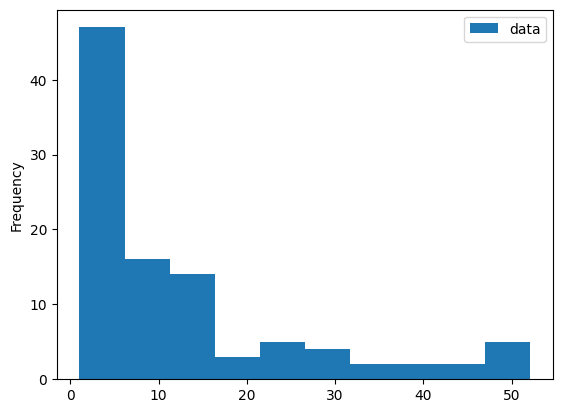

In [4]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

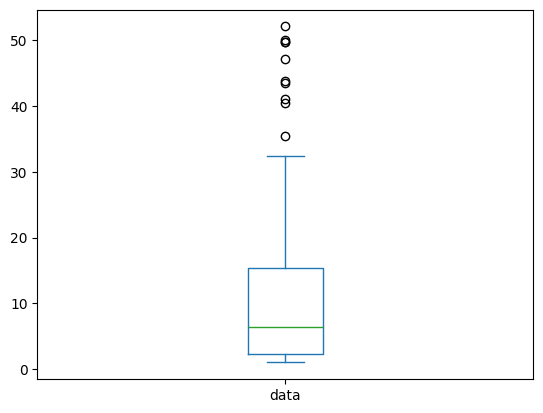

In [5]:
df.plot.box()

Both graphs show that the data is skewed. The histogram is better for audiences that do not have a science background as it is a visual that does not take a lot of effort to analyze. The box plot is better suited for those with a science background and more likely used in scientific research articles.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

## Dataset 1: Ransomware

In [6]:
# Setup the Ransomware dataset

# Ransomware
r1_df = pd.read_csv('ransomware_wannalocker_08212017_1.csv')
r2_df = pd.read_csv('ransomware_wannalocker_08212017_2.csv')
r3_df = pd.read_csv('ransomware_wannalocker_08212017_3.csv')

ransomware_df = pd.concat([r1_df, r2_df, r3_df], ignore_index=True)

# Normalize column names so headers like ' Flow Duration' become 'Flow Duration'
ransomware_df.columns = ransomware_df.columns.str.strip()

# Normalize label values for clearer visualization
if 'Label' in ransomware_df.columns:
    ransomware_df['Label'] = ransomware_df['Label'].astype(str).str.strip().replace({'RANSOMWARE_WANNALOCKER': 'WannaLocker'})

In [7]:
# Show the first few rows of the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,157.240.2.36-10.42.0.151-443-45492-6,157.240.2.36,443,10.42.0.151,45492,6,21/08/2017 03:17:33,38,2,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
1,157.240.2.36-10.42.0.151-443-45492-6,10.42.0.151,45492,157.240.2.36,443,6,21/08/2017 03:17:33,678,3,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
2,10.42.0.151-31.13.80.5-56334-443-6,10.42.0.151,56334,31.13.80.5,443,6,21/08/2017 03:17:57,226491,6,7,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
3,172.217.17.131-10.42.0.151-443-41602-6,10.42.0.151,41602,172.217.17.131,443,6,21/08/2017 03:17:45,26421468,4,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
4,172.217.10.74-10.42.0.151-443-58679-6,10.42.0.151,58679,172.217.10.74,443,6,21/08/2017 03:18:17,37272,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker


In [8]:
# Clean the Ransomware dataset

# Remove unnamed columns
ransomware_df = ransomware_df.loc[:, ~ransomware_df.columns.str.contains('^Unnamed')]

# Remove rows with NaN values
ransomware_df.dropna(inplace=True)

# Remove duplicates
ransomware_df.drop_duplicates(inplace=True)

# Identify file-size-like and time-like columns by keywords
file_size_keywords = ['length', 'bytes', 'size', 'packet']
time_keywords = ['duration', 'time', 'iat', 'active', 'idle']

file_size_cols = [c for c in ransomware_df.columns if any(k in c.lower() for k in file_size_keywords)]
time_cols = [c for c in ransomware_df.columns if any(k in c.lower() for k in time_keywords)]

# Coerce those columns to numeric so comparisons are safe
for c in set(file_size_cols + time_cols):
    ransomware_df[c] = pd.to_numeric(ransomware_df[c], errors='coerce')

# Check and report negative flow duration values
if 'Flow Duration' in ransomware_df.columns:
    neg_flow_duration_mask = ransomware_df['Flow Duration'] < 0
    neg_flow_duration_count = neg_flow_duration_mask.sum()
    print(f"Rows with negative flow duration: {neg_flow_duration_count}")
else:
    neg_flow_duration_mask = pd.Series(False, index=ransomware_df.index)
    print("Warning: Flow Duration column not found after cleanup.")

# Find rows with negative values in the selected file-size columns
neg_file_mask = (ransomware_df[file_size_cols] < 0).any(axis=1) if file_size_cols else pd.Series(False, index=ransomware_df.index)

# Drop rows that have negative file sizes or negative Flow Duration values
ransomware_df = ransomware_df.loc[~(neg_file_mask | neg_flow_duration_mask)].copy()

print(f"Rows with negative file sizes: {neg_file_mask.sum()}")

Rows with negative flow duration: 0
Rows with negative file sizes: 4891


Plotting 81 of 81 numeric columns.


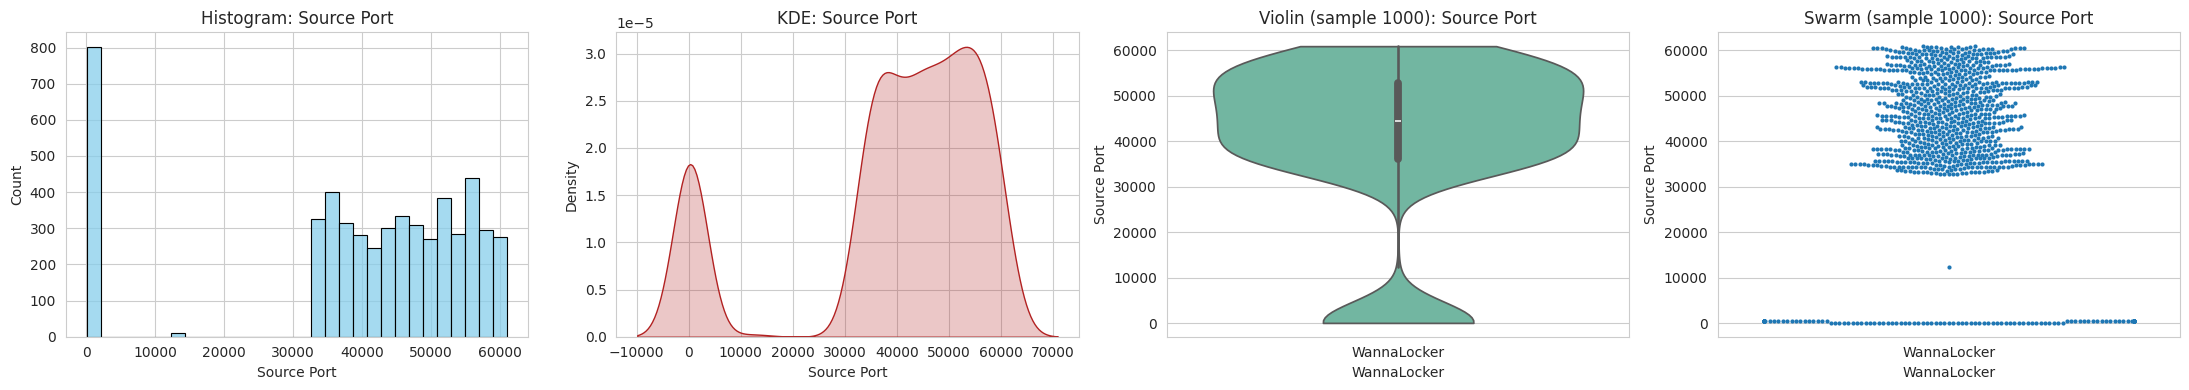

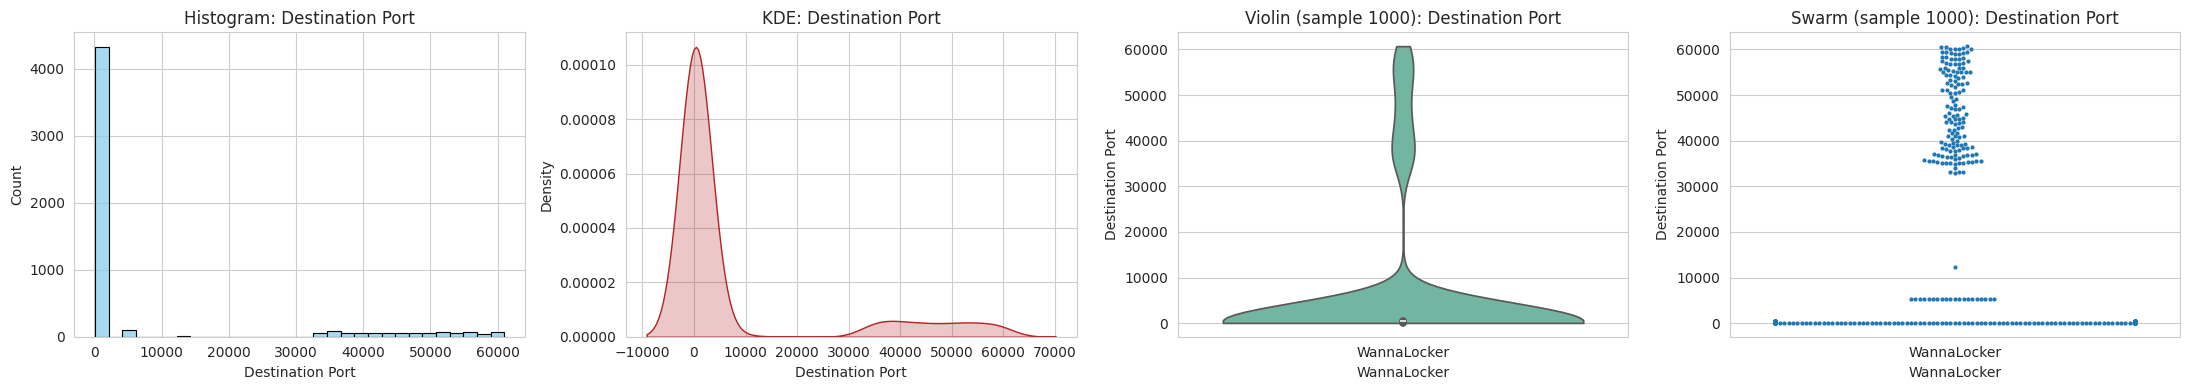

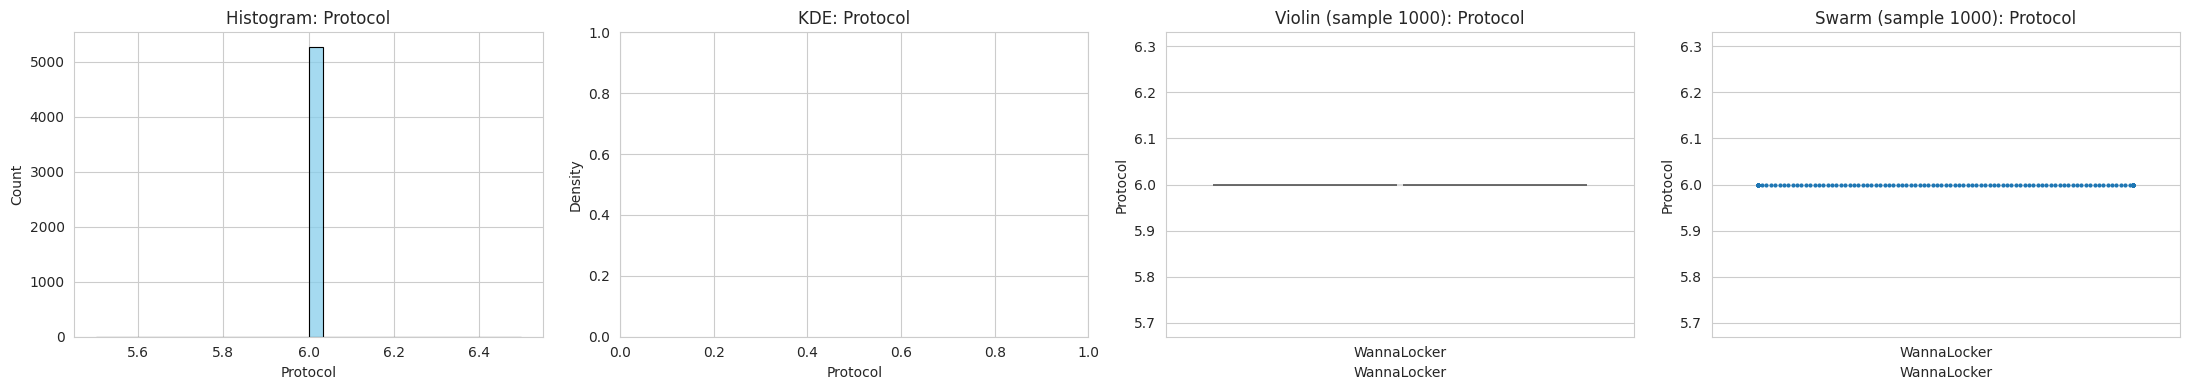

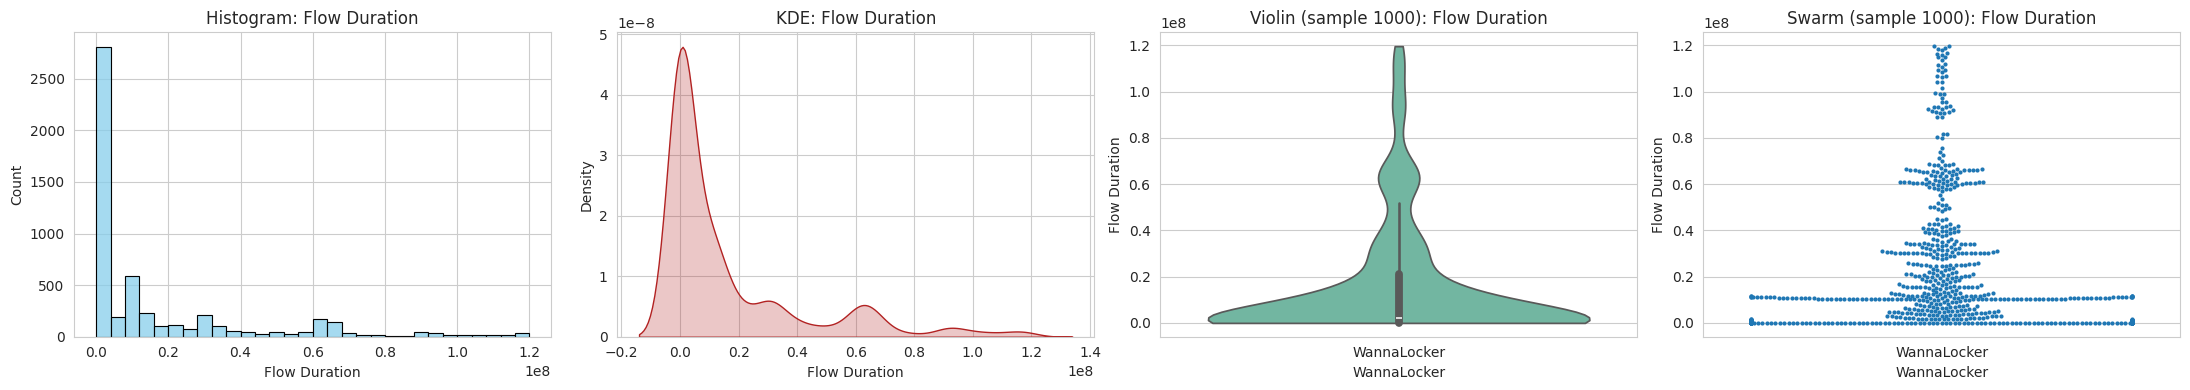

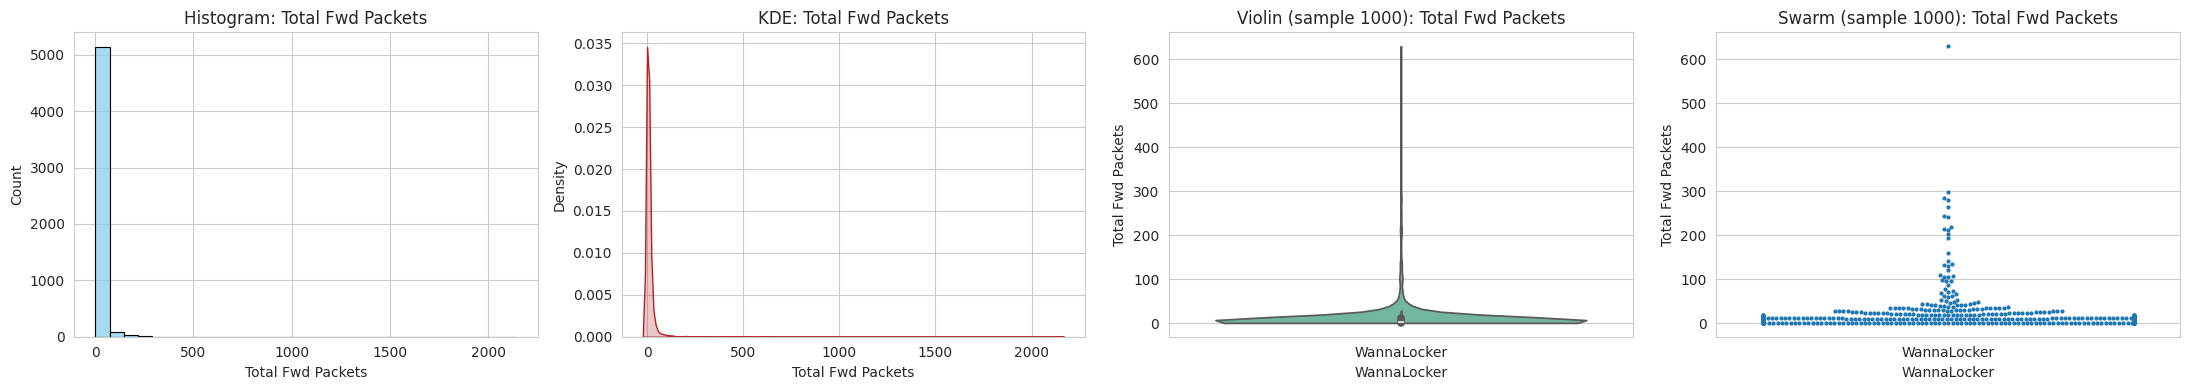

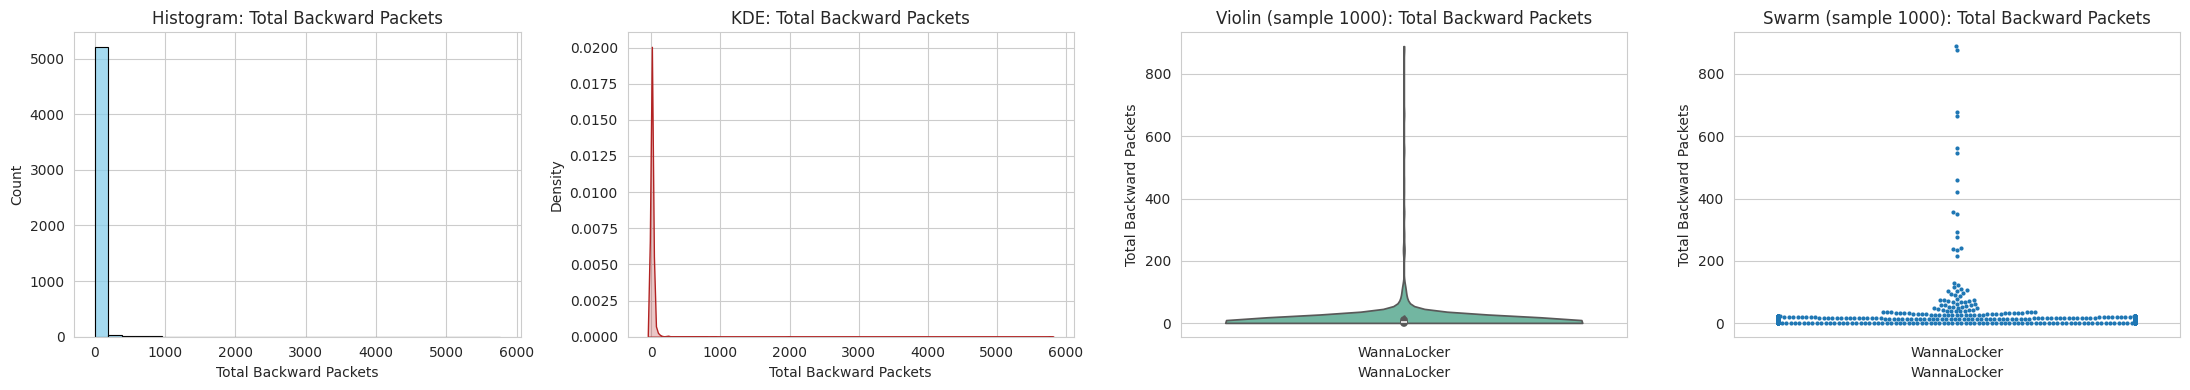

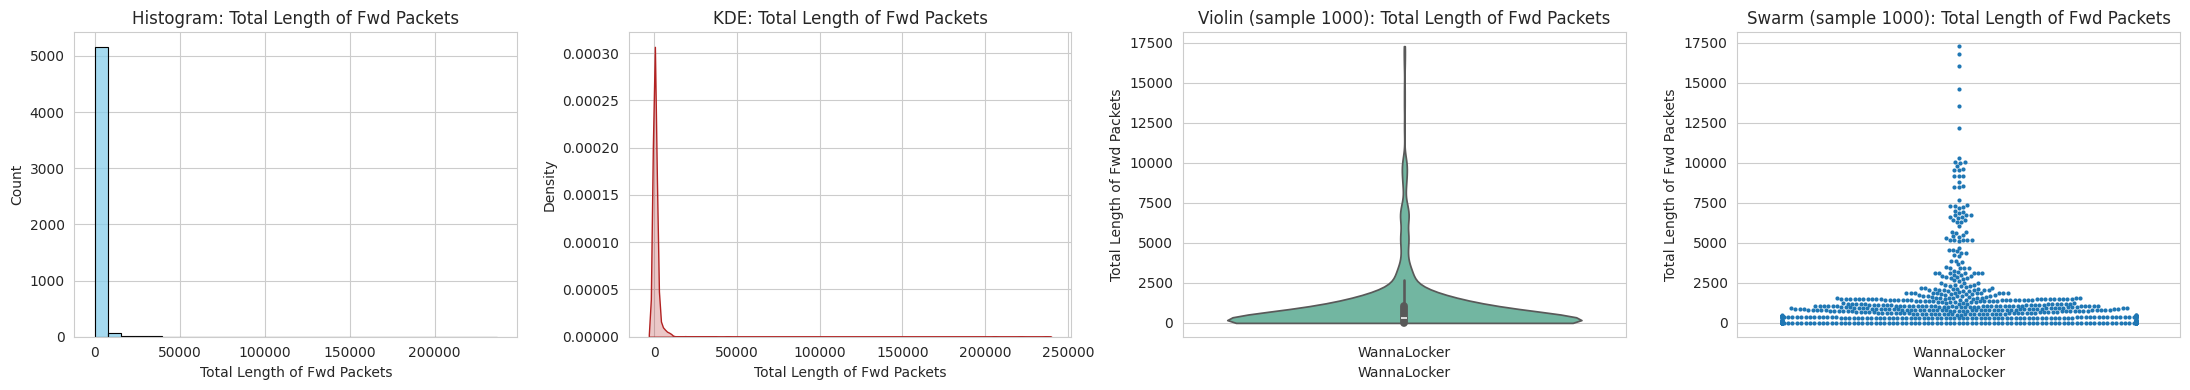

In [ ]:
# Draw histograms and histogram variants for each feature or column. (Swarm plot, kde plot, violin plot).

# Select numeric columns
numeric_cols = ransomware_df.select_dtypes(include=[np.number]).columns.tolist()

if not numeric_cols:
    print("No numeric columns found to plot.")
else:
    # Plot all numeric features
    max_plots = len(numeric_cols)
    cols_to_plot = numeric_cols[:max_plots]

    print(f"Plotting {len(cols_to_plot)} of {len(numeric_cols)} numeric columns.")

    sns.set_style('whitegrid')

    for col in cols_to_plot:
        # Prepare clean series (finite values only)
        series = pd.to_numeric(ransomware_df[col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if series.empty:
            continue

        fig, axes = plt.subplots(1, 4, figsize=(22, 4))

        # Histogram
        sns.histplot(series, bins=30, ax=axes[0], color='skyblue', edgecolor='black')
        axes[0].set_title(f'Histogram: {col}')

        # KDE
        try:
            sns.kdeplot(series, ax=axes[1], color='firebrick', fill=True)
            axes[1].set_title(f'KDE: {col}')
        except Exception:
            axes[1].text(0.5, 0.5, 'KDE failed', ha='center')
            axes[1].set_title(f'KDE: {col}')

        # Use a sampled subset of the data for violin and swarm plots
        if 'Label' in ransomware_df.columns:
            sample_n = min(1000, len(ransomware_df))
            sample_df = ransomware_df.sample(n=sample_n, random_state=42).copy()
            sample_df[col] = pd.to_numeric(sample_df[col], errors='coerce')
            sample_df = sample_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[col])

            sns.violinplot(data=sample_df, x='Label', y=col, ax=axes[2], palette='Set2', cut=0)
            axes[2].set_title(f'Violin (sample {sample_n}): {col}')
            # axes[2].set_xlabel('WannaLocker')

            try:
                sns.swarmplot(data=sample_df, x='Label', y=col, ax=axes[3], size=3)
                axes[3].set_title(f'Swarm (sample {sample_n}): {col}')
                # axes[3].set_xlabel('WannaLocker')
            except Exception:
                axes[3].text(0.5, 0.5, 'Swarm failed (too many points)', ha='center')
                axes[3].set_title('Swarm')
        else:
            axes[2].text(0.5, 0.5, 'No Label column', ha='center')
            axes[2].set_title('Violin')
            axes[3].text(0.5, 0.5, 'No Label column', ha='center')
            axes[3].set_title('Swarm')

        plt.tight_layout()
        plt.show()

    if len(numeric_cols) > max_plots:
        print(f"Note: {len(numeric_cols)-max_plots} additional numeric columns not plotted. Increase `max_plots` to include them.")


TypeError: object of type 'NoneType' has no len()

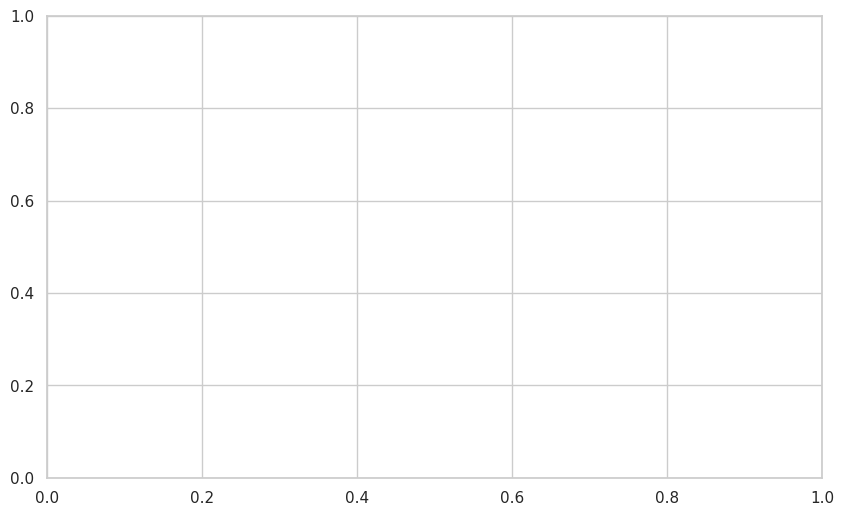

In [11]:
# Draw grouped histograms. For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a grouped histogram using the cleaned 'Flow Duration' column and the label grouping
plt.figure(figsize=(10, 6))
sns.histplot(
    data=ransomware_df, 
    x="Flow Duration", 
    hue="Label", 
    multiple="dodge", # Groups bars side-by-side
    shrink=.8,
    palette="deep"
)

plt.title("Grouped Histogram of Flow Duration by Forward Packets")
plt.xlabel("Flow Duration")
plt.ylabel("Count")
plt.show()

In [ ]:
# Draw a bar plot to indicate total counts of each categorical variable in a given column.

# Set the theme style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

# Plot total counts for each category
# Replace "Label" with any categorical column name (e.g., "Protocol", "Source IP")
sns.countplot(
    data=df, 
    x="Label", 
    palette="viridis",
    hue="Label",       # Optional: adds color mapping per category
    legend=False
)

# Add exact count values on top of each bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                xytext=(0, 5), textcoords='offset points')

plt.title("Total Counts per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45) # Rotates labels if they overlap
plt.tight_layout()
plt.show()

In [ ]:
# Find means, medians, and modes.

# Select only numeric columns for mean and median calculations
numeric_df = df.select_dtypes(include=['number'])

# Calculate metrics
means = numeric_df.mean()
medians = numeric_df.median()
modes = df.mode().iloc[0] # Mode works on both numeric and categorical columns

# Combine them into a clean summary DataFrame
summary_df = pd.DataFrame({
    'Mean': means,
    'Median': medians,
    'Mode': modes[numeric_df.columns] # Match mode rows to numeric columns
})

print("--- Statistical Summary ---")
print(summary_df)

## Dataset 2: Misinformation

In [ ]:
# Setup the Misinformation dataset

# Misinformation
m1_df = pd.read_csv('misinformation.csv', encoding='latin1', dtype=str)

m1_df = m1_df.loc[:, ~m1_df.columns.str.contains('^Unnamed')]
misinformation_df = m1_df

misinformation_df['label'] = misinformation_df['label'].astype(str).str.strip().map({'0': 'fake', '1': 'real'})

In [ ]:
# Show the first few rows of the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,real
1,NaN,Did they post their votes for Hillary already?,real
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",real
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,fake
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",real


In [ ]:
# Clean the Misinformation dataset

# Remove unnamed columns
misinformation_df = misinformation_df.loc[:, ~misinformation_df.columns.str.contains('^Unnamed')]

# Track row count before cleaning
initial_rows = len(misinformation_df)

# Remove all of the rows with NaN values
misinformation_df.dropna(inplace=True)

# Remove the duplicates
misinformation_df.drop_duplicates(inplace=True)

# Report how many rows were removed by cleaning
cleaned_rows = len(misinformation_df)
print(f"Rows with NaN values or rows with duplicates: {initial_rows - cleaned_rows}")

NameError: name 'misinformation_df' is not defined

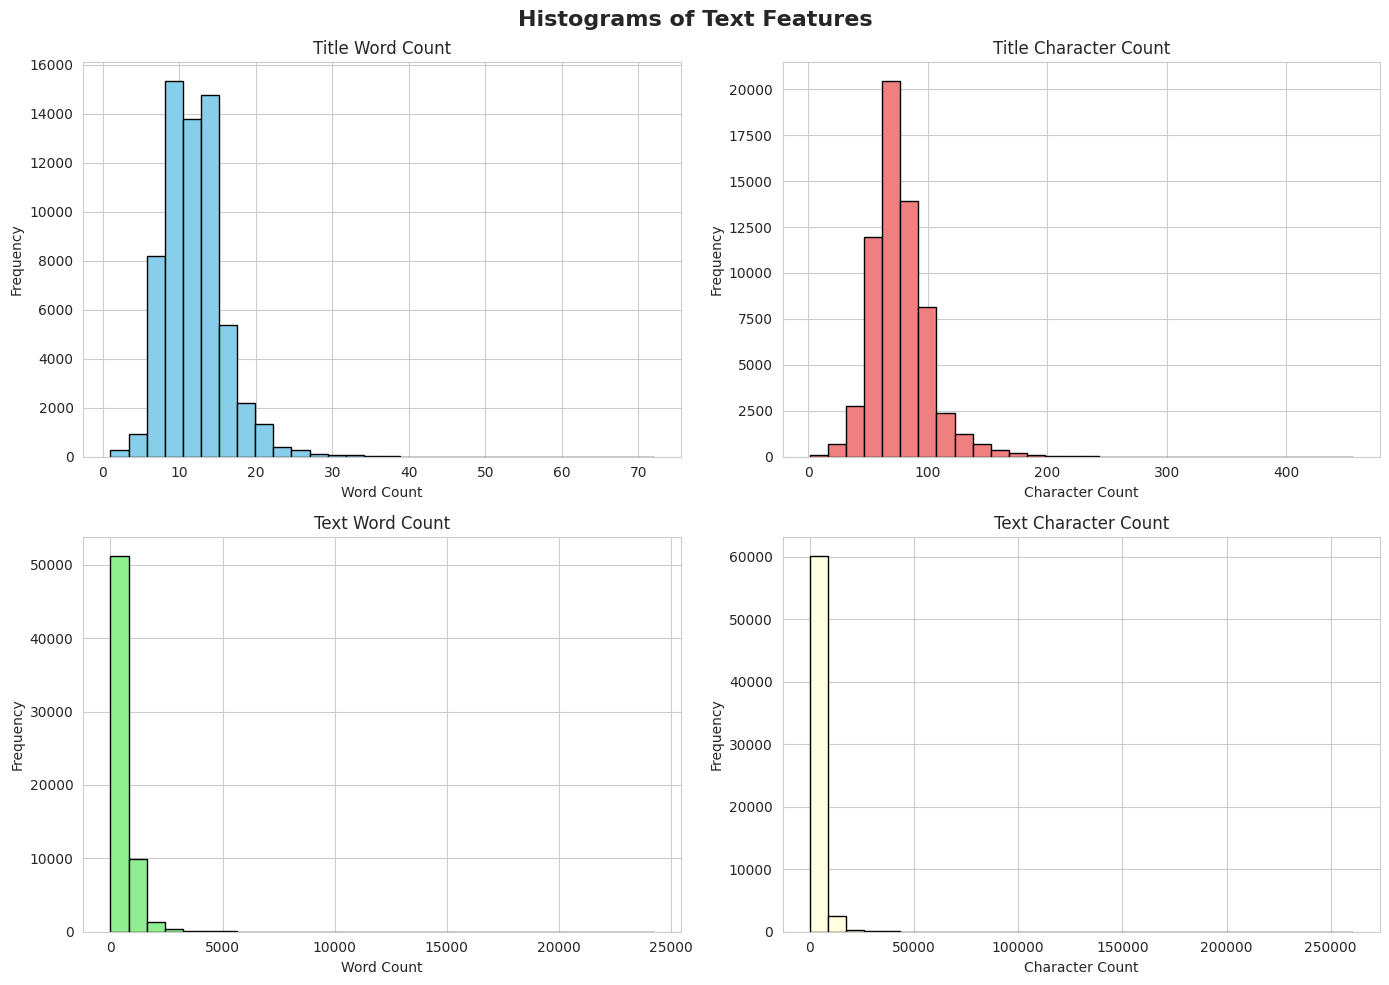

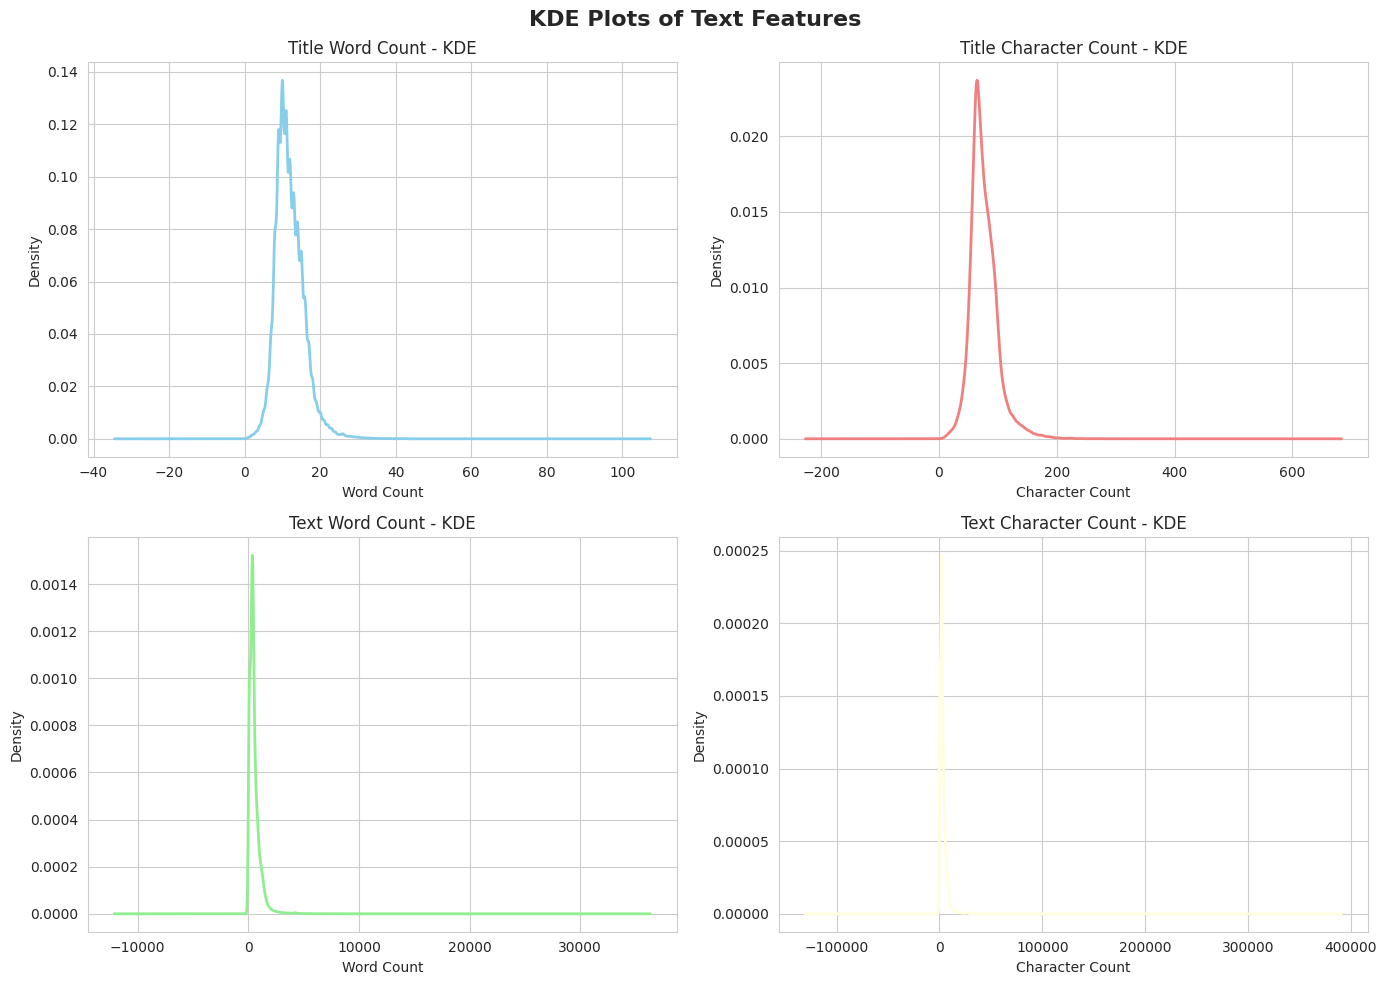

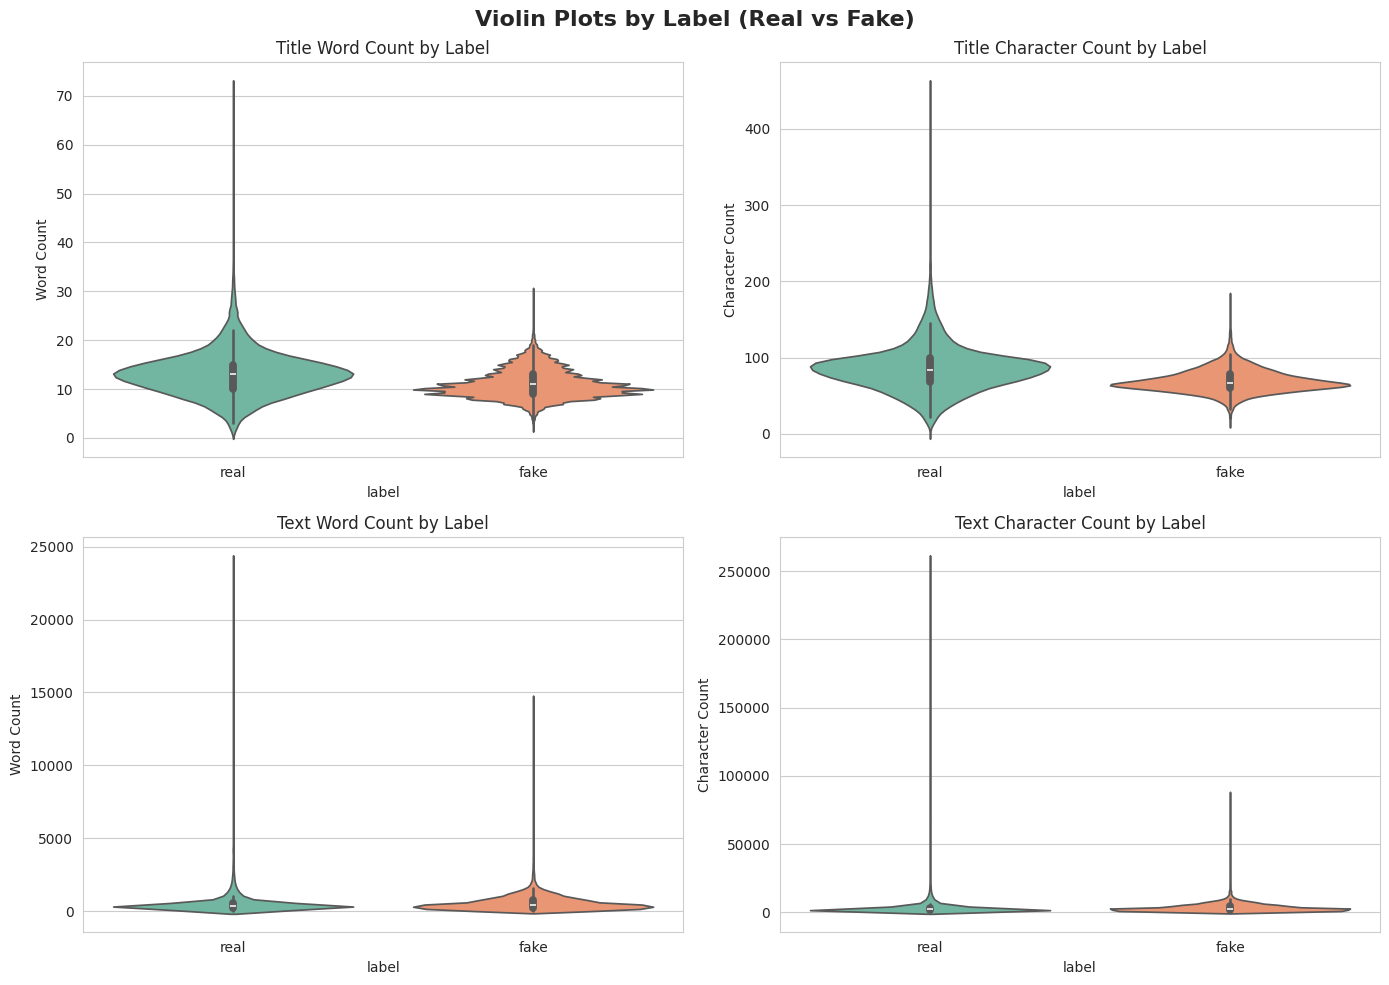

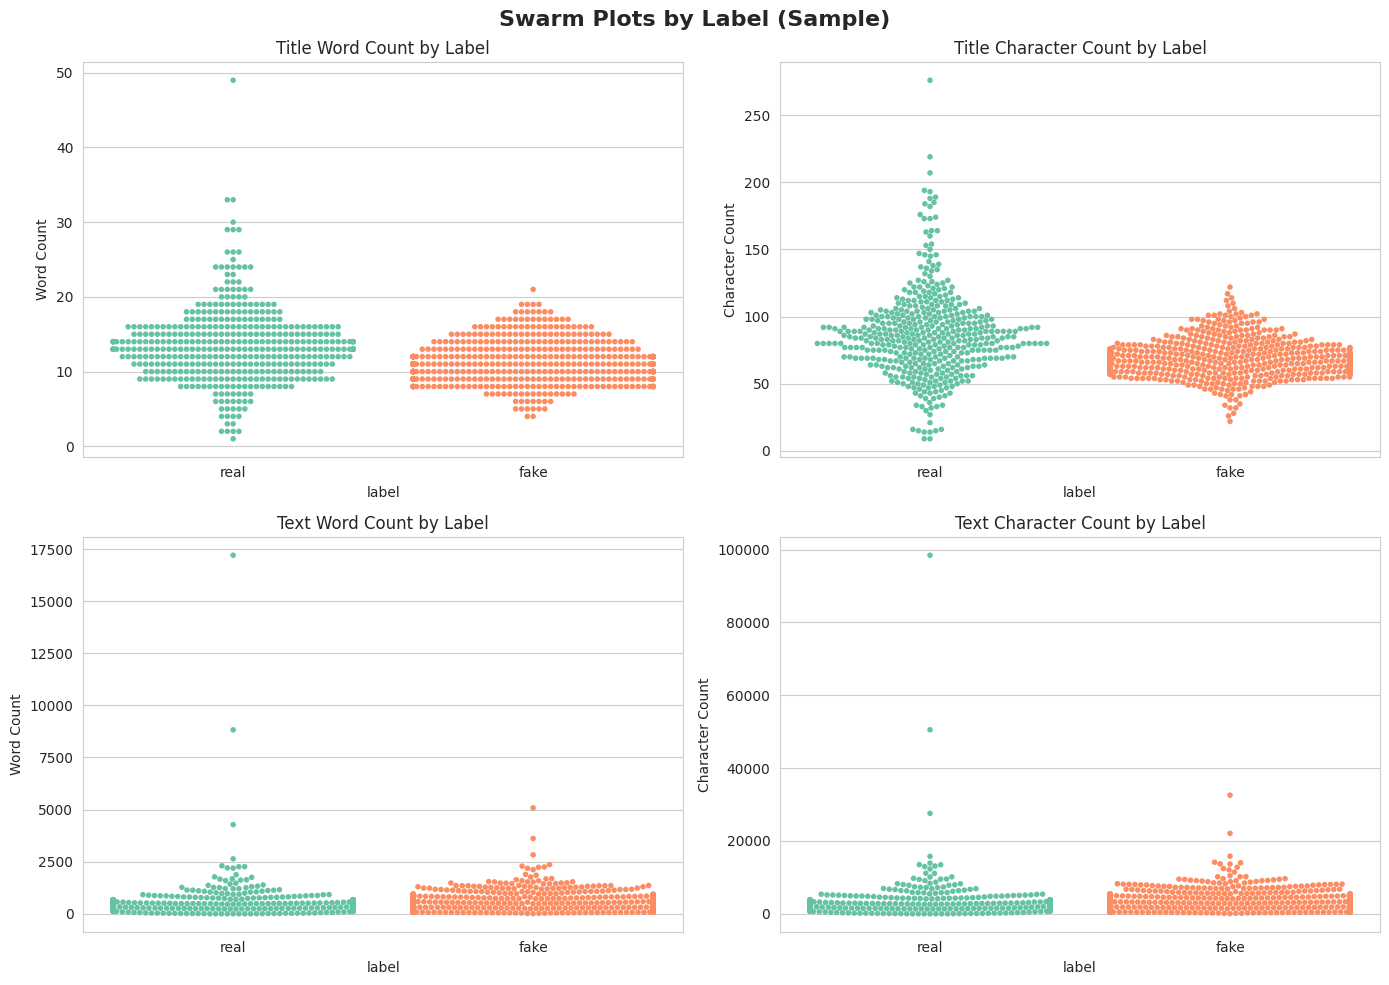

In [ ]:
# Draw histograms and histogram variants for each feature or column. (Swarm plot, kde plot, violin plot).

# Create numeric features from text columns
misinformation_df['title_word_count'] = misinformation_df['title'].str.split().str.len()
misinformation_df['text_word_count'] = misinformation_df['text'].str.split().str.len()
misinformation_df['title_char_count'] = misinformation_df['title'].str.len()
misinformation_df['text_char_count'] = misinformation_df['text'].str.len()

numeric_cols = ['title_word_count', 'title_char_count', 'text_word_count', 'text_char_count']

sns.set_style('whitegrid')

for col in numeric_cols:
    series = pd.to_numeric(misinformation_df[col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if series.empty:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))

    # Histogram
    sns.histplot(series, bins=30, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Histogram: {col}')

    # KDE
    try:
        sns.kdeplot(series, ax=axes[1], color='firebrick', fill=True)
        axes[1].set_title(f'KDE: {col}')
    except Exception:
        axes[1].text(0.5, 0.5, 'KDE failed', ha='center')
        axes[1].set_title(f'KDE: {col}')

    # Violin plot by Label
    sns.violinplot(data=misinformation_df, x='label', y=col, ax=axes[2], palette='Set2', cut=0)
    axes[2].set_title(f'Violin by Label: {col}')

    # Swarm plot (sampled) by Label to avoid overcrowding
    sample_n = min(500, len(misinformation_df))
    sample_df = misinformation_df.sample(n=sample_n, random_state=42)
    sample_df[col] = pd.to_numeric(sample_df[col], errors='coerce')
    sample_df = sample_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[col])
    try:
        sns.swarmplot(data=sample_df, x='label', y=col, ax=axes[3], size=3)
        axes[3].set_title(f'Swarm (sample {sample_n}) by Label: {col}')
    except Exception:
        axes[3].text(0.5, 0.5, 'Swarm failed (too many points)', ha='center')
        axes[3].set_title('Swarm')

    plt.tight_layout()
    plt.show()

if len(numeric_cols) > 4:
    print(f"Note: only {len(numeric_cols)} numeric columns were plotted with the ransomware-style layout.")

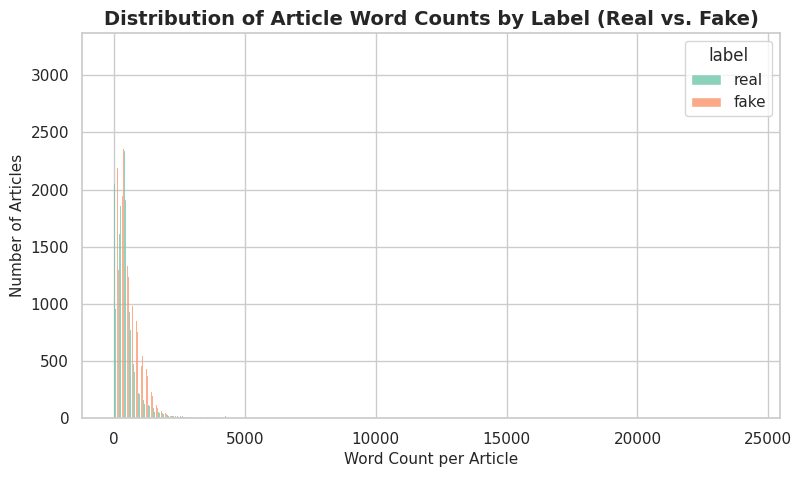

In [ ]:
# Draw grouped histograms. For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

# Set a clean layout theme
sns.set_theme(style="whitegrid")

# Create the visualization
plt.figure(figsize=(9, 5))
sns.histplot(
    data=misinformation_df, 
    x="text_word_count", 
    hue="label", 
    multiple="dodge",     # Groups the bars side-by-side
    shrink=0.8,           # Creates clear visual gaps between groups
    palette="Set2"        # Color scheme distinguishing groups
)

# Apply context-specific labels and titles
plt.title("Distribution of Article Word Counts by Label (Real vs. Fake)", fontsize=14, fontweight='bold')
plt.xlabel("Word Count per Article", fontsize=11)
plt.ylabel("Number of Articles", fontsize=11)

plt.show()

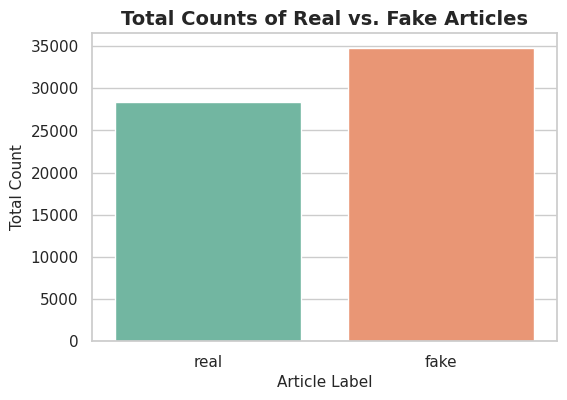

In [ ]:
# Draw a bar plot to indicate total counts of each categorical variable in a given column.

# Create the categorical count plot using the 'label' column
plt.figure(figsize=(6, 4))
sns.countplot(
    data=misinformation_df, 
    x="label", 
    palette="Set2"
)

# Add titles and axis labels
plt.title("Total Counts of Real vs. Fake Articles", fontsize=14, fontweight='bold')
plt.xlabel("Article Label", fontsize=11)
plt.ylabel("Total Count", fontsize=11)

plt.show()

In [ ]:
# Find means, medians, and modes.

# Calculate individual statistics
mean_val = misinformation_df['text_word_count'].mean()
median_val = misinformation_df['text_word_count'].median()

# Mode returns a Series because data can have multiple modes
mode_vals = misinformation_df['text_word_count'].mode().tolist() 

print(f"Mean:   {mean_val:.2f}")
print(f"Median: {median_val}")
print(f"Mode(s): {mode_vals}")

Mean:   546.79
Median: 404.0
Mode(s): [0]


## Conclusions

Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

Are there any outliers present?  (Data points that are far from the others.)

If there are multiple related histograms, how does the distribution change across different groups?

What are the minimum and maximum values represented in each histogram?

How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

Does the distribution appear normal, or does it have a different distribution?

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

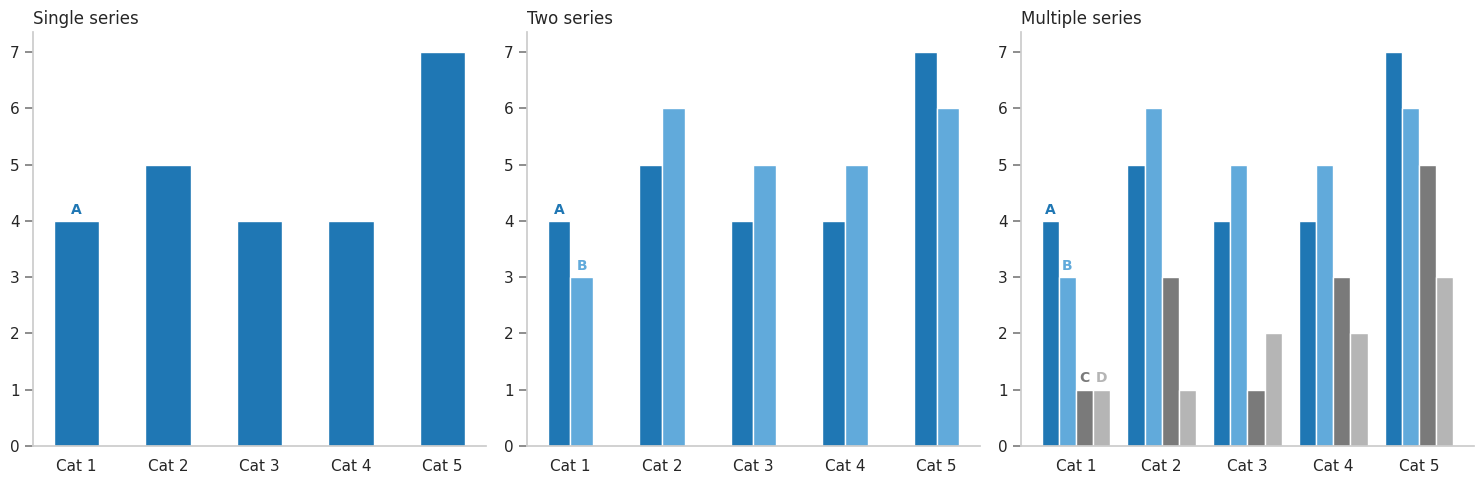

In [ ]:

# Three Vertical Bar Charts (Figure 2.15 on pg. 54)

# Data generation
categories = ['Cat 1', 'Cat 2', 'Cat 3', 'Cat 4', 'Cat 5']
x = np.arange(len(categories))

# Width management
width = 0.25
multi_width = 0.2

# Subplots Configuration
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Chart 1: Single Series
single_data = [4, 5, 4, 4, 7]
ax1.bar(x, single_data, width=0.5, color='#1f77b4', label='A')

ax1.set_title('Single series', loc='left')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)

# Chart 2: Two Series
two_series_1 = [4, 5, 4, 4, 7]
two_series_2 = [3, 6, 5, 5, 6]

ax2.bar(x - width/2, two_series_1, width, color='#1f77b4', label='A')
ax2.bar(x + width/2, two_series_2, width, color='#61aadb', label='B')

ax2.set_title('Two series', loc='left')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)

# Chart 3: Multi-Series (Four Series Grouped Side-by-Side)
multi_1 = [4, 5, 4, 4, 7]
multi_2 = [3, 6, 5, 5, 6] 
multi_3 = [1, 3, 1, 3, 5]
multi_4 = [1, 1, 2, 2, 3]

ax3.bar(x - 1.5 * multi_width, multi_1, multi_width, color='#1f77b4', label='A')
ax3.bar(x - 0.5 * multi_width, multi_2, multi_width, color='#61aadb', label='B')
ax3.bar(x + 0.5 * multi_width, multi_3, multi_width, color="#7A7A7A", label='C')
ax3.bar(x + 1.5 * multi_width, multi_4, multi_width, color='#b5b5b5', label='D')

ax3.set_title('Multiple series', loc='left')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)

# Style customization, spine removal, disable grid lines, and color each bar label same as bar
for ax in [ax1, ax2, ax3]:
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    
    # Remove top and right borders (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Show y-axis ticks
    ax.tick_params(axis='y', which='both', left=True, labelleft=True, direction='out', color='gray')

    # Disable grid lines
    ax.grid(False)

    # Generate colored labels only for the first bar index
    for container in ax.containers:
        series_label = container.get_label()
        
        # Pull the RGB/RGBA color value directly from the first bar patch
        bar_color = container.patches[0].get_facecolor()
        
        # Only show the name for the first category item
        custom_labels = [series_label if i == 0 else "" for i in range(len(categories))]
        
        # Pass the extracted color into label_color
        ax.bar_label(container, labels=custom_labels, padding=3, fontsize=10, color=bar_color, weight='bold')

# Layout optimization
plt.tight_layout()
plt.show()